# CAFE — composed pipelines

The quickstart used a **black-box** system: you wrap an existing system in one
`run(config, item)` and CAFE sees only inputs → outputs. Here we use the **composed**
style: you build the system out of **techniques** registered on a **`cafe.Pipeline`** you
own, and call them through an instrumented context `ctx`. CAFE then sees *inside* — so it can:

- **swap techniques as factors** (a factor per *stage*, levels = your techniques),
- record **per-stage** time / tokens / cost and a **trace** of every run,
- auto-detect the **pipeline order**,
- run the same judging + statistics (interactions, Pareto, plots) as before.

The pipeline **owns its techniques** — no global state, and two pipelines never interfere.
We build a small RAG-style pipeline — **retrieve → rerank → generate** — and vary it three
ways in one factorial.

In [ ]:
import cafe
from cafe._env import load_env

load_env()
pipe = cafe.Pipeline()   # techniques register onto THIS pipeline (no global state, no clear())
print("cafe", cafe.__version__)

## 1. Register techniques

Each technique has a **stage** (its role) and a **name** (this implementation). The
function's arguments split by whether they have a default: no default = a runtime input
you pass via `ctx.run` (`query`, `chunks`); *with* a default = a tunable knob (`top_k`).

A technique can declare a fixed **`cost_usd`** for a non-LLM component CAFE can't price
(here toy retrievers), or call `ctx.add_cost(...)` for a variable cost. LLM cost is
tracked automatically from `cafe.complete`.

In [ ]:
MODEL = "ollama_cloud/gpt-oss:120b"
CORPUS = [
    "Common misconceptions are widely believed but false.",
    "The Great Wall of China is not visible from space with the naked eye.",
    "Goldfish have a memory span of months, not seconds.",
    "Humans use far more than 10% of their brains.",
]

# ── retrieve: two techniques, a tunable top_k, and two ways to record a non-LLM cost ──
@pipe.technique("retrieve", "first", cost_usd=0.0005)   # fixed cost per call
async def retrieve_first(ctx, query, top_k=2):
    return CORPUS[:top_k]

@pipe.technique("retrieve", "keyword")                  # variable cost, computed below
async def retrieve_keyword(ctx, query, top_k=2):
    q = set(query.lower().split())
    ranked = sorted(CORPUS, key=lambda c: len(q & set(c.lower().split())), reverse=True)
    ctx.add_cost(0.0004 * top_k)   # e.g. a metered API: more docs ⇒ more $
    return ranked[:top_k]

# ── rerank: an LLM-free reranker (we'll also allow turning it OFF as a factor) ──
@pipe.technique("rerank", "by_length")
async def rerank_by_length(ctx, chunks):
    return sorted(chunks, key=len, reverse=True)

# ── generate: the answer, grounded in the retrieved context ──
@pipe.technique("generate", "grounded")
async def generate_grounded(ctx, query, chunks):
    context = "\n".join(chunks)
    return await cafe.complete(MODEL, [
        {"role": "system", "content": f"Answer truthfully and concisely. Context:\n{context}"},
        {"role": "user", "content": query}])

print("stages:", pipe.stages())

## 2. Compose them into a system

The topology is just your Python — retrieve, then rerank, then generate. CAFE watches
each `ctx.run` (so the order is *observed*, not hard-coded).

In [ ]:
@pipe.compose                                           # mark this as the pipeline's system fn
async def rag(config, item, ctx):
    chunks = await ctx.run("retrieve", query=item["text"])
    chunks = await ctx.run("rerank", chunks=chunks)     # may be skipped (see below)
    return await ctx.run("generate", query=item["text"], chunks=chunks)

## 3. Vary it three ways — the three kinds of factor

A factor is always just a **`cafe.Factor(name, levels)`** — a name + levels, crossed
factorially. In a composed pipeline there are three natural things to vary:

1. **which technique** fills a stage — `Factor("retrieve", ["first", "keyword"])`;
2. **a technique's knob** — `Factor("retrieve.top_k", [1, 2])` (the `"stage.param"` name);
3. **a stage on / off** — add a **`None`** level: `Factor("rerank", ["by_length", None])`.
   `None` means "skip this stage" — CAFE passes its sole input straight through (no no-op
   function). It shows up everywhere as a clean `none` label; using `None` (not the string
   `"none"`) means it can never clash with a real technique name.

> *Optional sugar:* `pipe.factor("retrieve")` auto-fills the levels from every technique
> registered under a stage on this pipeline (handy when a stage's techniques are discovered
> dynamically), and `pipe.factor("rerank", none="input_name")` skips a stage that has
> *several* inputs (naming which one to keep). Plain `cafe.Factor` covers everything above.

In [ ]:
study = cafe.Study(
    name="rag",
    system=pipe,                                             # the pipeline is the system
    factors=[
        cafe.Factor("retrieve", ["first", "keyword"]),       # 1: which retriever
        cafe.Factor("retrieve.top_k", [1, 2]),               # 2: its top_k knob
        cafe.Factor("rerank", ["by_length", None]),          # 3: rerank on/off (None skips it)
        cafe.Factor("generate", ["grounded"]),               # fixed (one level)
    ],
    dataset=cafe.datasets.load_truthfulqa(n=4, categories=["Misconceptions"], seed=1),
    rubric=cafe.ANSWER_QUALITY_1_5,
    judge=cafe.LLMJudge(model=MODEL),
)
study   # 2 × 2 × 2 × 1 = 8 configurations

### CAFE detects the pipeline for you

`cafe.pipeline(study)` runs **one configuration once** and reports the observed **stage
order** and each stage's **levels** — a rendered map of your pipeline. Note `rerank` has a
`none` level (the on/off skip).

In [5]:
print(cafe.pipeline(study).show())

pipeline:  retrieve  →  rerank  →  generate

  retrieve       levels: first, keyword
  rerank         levels: by_length, None
  generate       levels: grounded


In [6]:
cafe.pipeline(study)

stage,levels
retrieve,"first, keyword"
rerank,"by_length, None"
generate,grounded


In [7]:
result = study.evaluate(concurrency=4)
result

/tmp/ipykernel_1863634/1587636768.py:1: UserWarning: design check: 4 inputs — the mixed-effects models (linear / CLMM / logistic) estimate a per-question random intercept; with fewer than ~8 questions those estimates can be near-singular/unstable. Add inputs for reliable p-values
  result = study.evaluate(concurrency=4)
/tmp/ipykernel_1863634/1587636768.py:1: UserWarning: design check: 8 configurations but only 4 inputs — few observations per configuration; per-factor estimates will be weak. Add inputs, or reduce factors/levels
  result = study.evaluate(concurrency=4)


rag: answers:   0%|          | 0/32 [00:00<?, ?it/s]

judging:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluation(32 answers · 8 configs · 4 inputs · 32 ratings · best: generate=grounded·rerank=by_length·retrieve=first·retrieve.top_k=1)

## 4. Per-stage view (the composed payoff)

Every `ctx.run` was timed and metered, so we see where time / tokens / cost go per
stage — impossible for a black box. `retrieve` carries only its declared `cost_usd`;
`generate` carries the LLM tokens; a skipped `rerank` (`none`) is ~instant and free.

In [8]:
import pandas as pd
pd.DataFrame(cafe.stage_report(result.answers))

,stage,technique,calls,mean_elapsed_s,mean_cost_usd,mean_tokens
0,generate,grounded,32,43.0532,0.0000,472.7
1,retrieve,first,16,0.0000,0.0005,0.0
2,rerank,by_length,16,0.0000,0.0000,0.0
3,rerank,none,16,0.0000,0.0000,0.0
4,retrieve,keyword,16,0.0000,0.0006,0.0


In [9]:
# the exact sequence one run went through (per-stage time, tokens, cost)
pd.DataFrame(result.answers.observations[-1].metadata["trace"])

,stage,technique,params,elapsed_s,cost_usd,tokens,cached
0,retrieve,keyword,{'top_k': 2},0.00002,0.0008,0,False
1,rerank,none,{},0.00000,0.0000,0,False
2,generate,grounded,{},36.65735,0.0000,653,False


## 5. Statistics & plots — same engine as the quickstart

`result.report()` gives all three layers in one call. With several stages as factors, the
two-way **interactions** are estimated automatically (does reranking help more with one
retriever than the other?).

In [10]:
print(result.report())

32 answers · 8 configs · 4 inputs · 32 ratings · best: generate=grounded·rerank=by_length·retrieve=first·retrieve.top_k=1

pipeline: 32 answers  →  32 judged  →  32 usable verdict(s)

────────────────────────────────────────────────────────────
DESCRIPTIVE — means & best configuration
────────────────────────────────────────────────────────────
verdicts: 32   factors: retrieve, retrieve.top_k, rerank, generate

overall mean quality: 4.81  (n=32)

per-configuration mean quality:
  5.00  (n= 4)  generate=grounded·rerank=by_length·retrieve=first·retrieve.top_k=1
  5.00  (n= 4)  generate=grounded·rerank=none·retrieve=first·retrieve.top_k=1
  5.00  (n= 4)  generate=grounded·rerank=by_length·retrieve=first·retrieve.top_k=2
  5.00  (n= 4)  generate=grounded·rerank=none·retrieve=first·retrieve.top_k=2
  5.00  (n= 4)  generate=grounded·rerank=by_length·retrieve=keyword·retrieve.top_k=1
  4.75  (n= 4)  generate=grounded·rerank=by_length·retrieve=keyword·retrieve.top_k=2
  4.75  (n= 4)  generate=

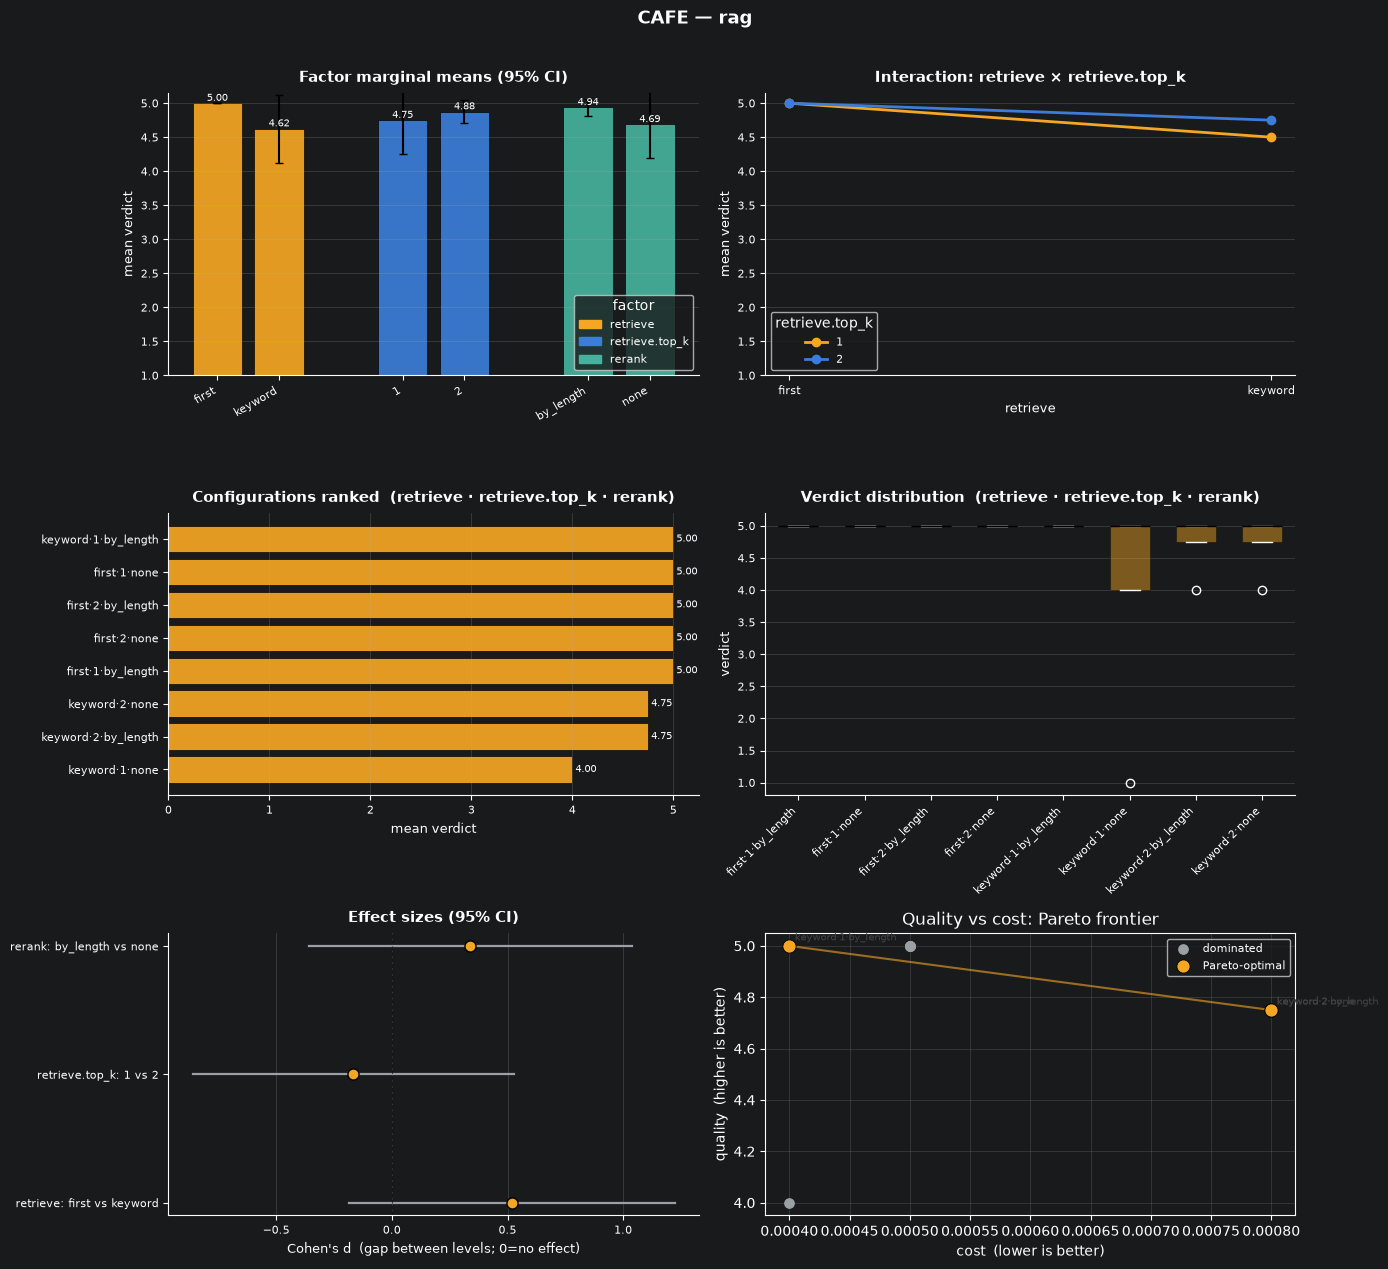

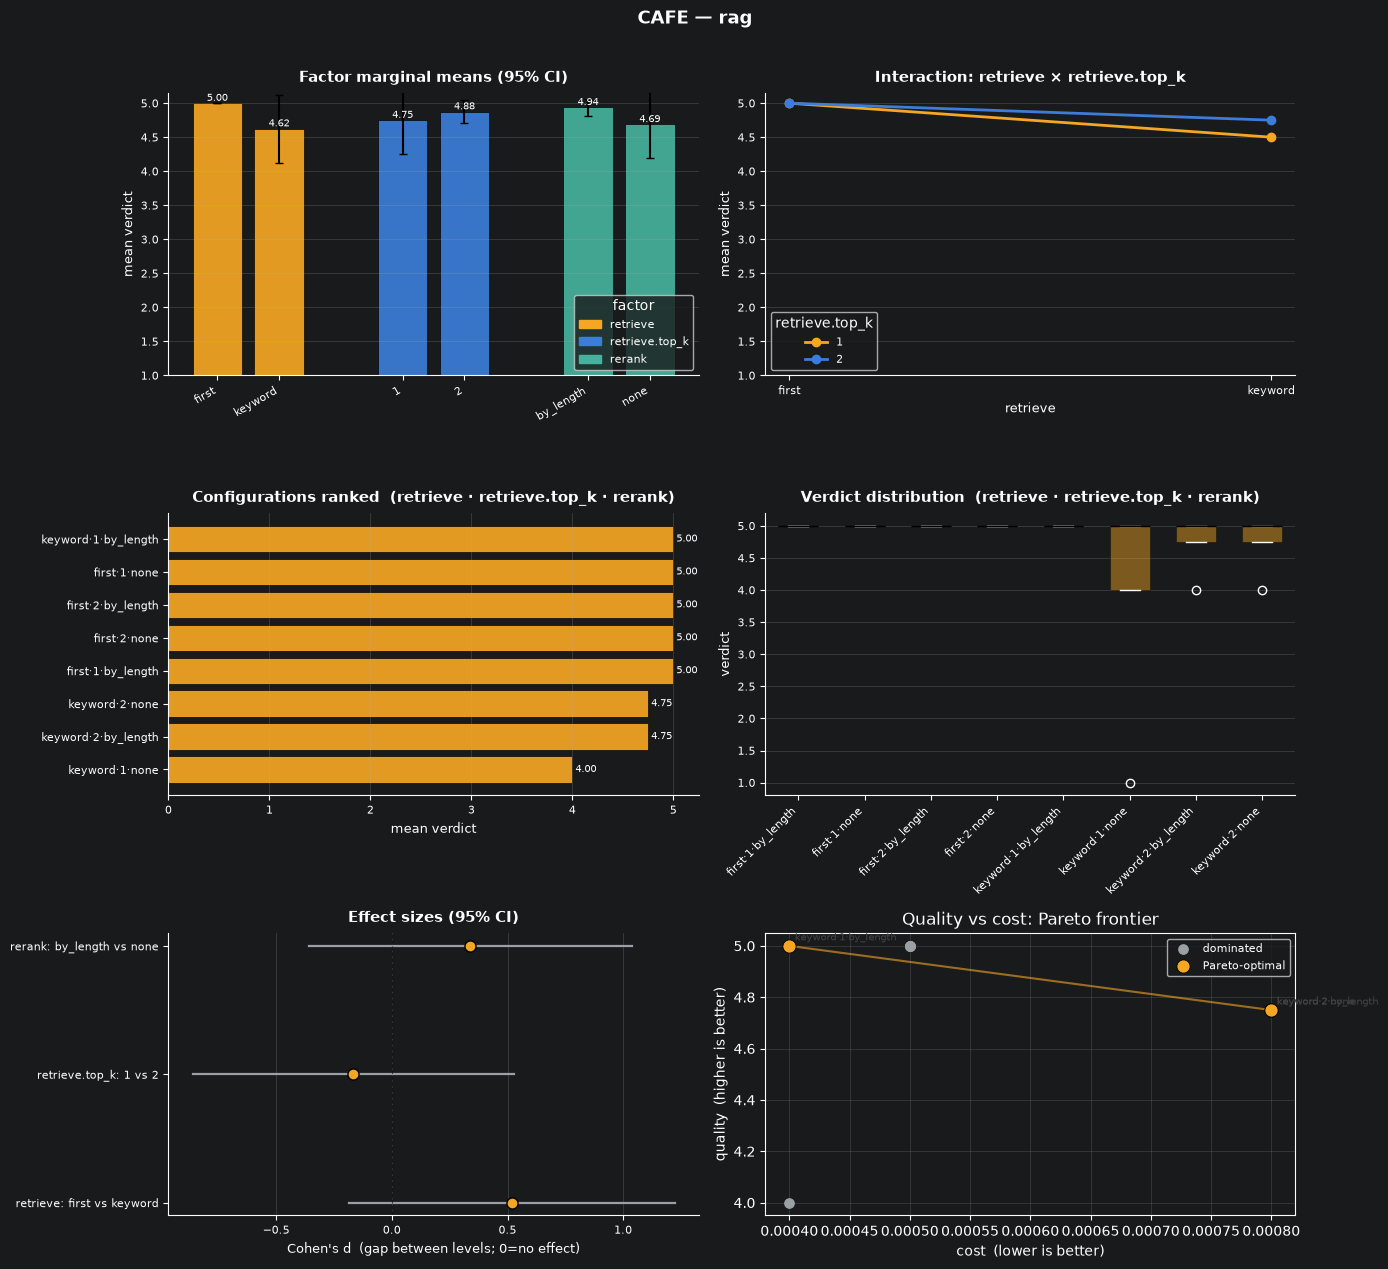

In [11]:
result.plot()   # dashboard; Pareto here trades quality vs cost/tokens (metered per stage)

### Overriding an LLM's price

Auto LLM cost comes from LiteLLM's price tables. For a subscription, a negotiated rate,
self-hosting, or a provider LiteLLM doesn't price (Ollama Cloud reports \$0), set your
own — it flows into the per-stage cost, Pareto and `report()`.

In [12]:
cafe.set_model_cost(MODEL, per_1k_tokens=0.10)   # $0.10 per 1k tokens, say
repriced = study.evaluate(concurrency=4)
pd.DataFrame(cafe.stage_report(repriced.answers))[["stage", "technique", "mean_tokens", "mean_cost_usd"]]

/tmp/ipykernel_1863634/675078103.py:2: UserWarning: design check: 4 inputs — the mixed-effects models (linear / CLMM / logistic) estimate a per-question random intercept; with fewer than ~8 questions those estimates can be near-singular/unstable. Add inputs for reliable p-values
  repriced = study.evaluate(concurrency=4)
/tmp/ipykernel_1863634/675078103.py:2: UserWarning: design check: 8 configurations but only 4 inputs — few observations per configuration; per-factor estimates will be weak. Add inputs, or reduce factors/levels
  repriced = study.evaluate(concurrency=4)


rag: answers:   0%|          | 0/32 [00:00<?, ?it/s]

judging:   0%|          | 0/32 [00:00<?, ?it/s]

,stage,technique,mean_tokens,mean_cost_usd
0,generate,grounded,450.2,0.045025
1,retrieve,first,0.0,0.000500
2,rerank,by_length,0.0,0.000000
3,rerank,none,0.0,0.000000
4,retrieve,keyword,0.0,0.000600


## Notes

- **Stages are yours** — `retrieve`/`rerank`/`generate` are names you chose, not fixed
  slots. The topology is your Python; add branches, cascades, loops.
- **Three factor kinds, one mechanism** — swap a technique, sweep a `stage.param` knob, or
  toggle a stage `none` on/off; all are just factors with levels, crossed factorially.
- **Cost** = automatic LLM cost (via `cafe.complete`) + a technique's `cost_usd=` + any
  `ctx.add_cost(...)`, with `cafe.set_model_cost(...)` to override an LLM's price.
- **Per-stage time / tokens / cost + the full trace** are captured for every run — the
  transparency you get from the composed style that a black box can't give you.